## Clustering de Clientes con K-Means

### Por: Grupo 12 - ITBA
### Fecha: 2026-04-15

### Descripcion:
Segmentacion de 4,338 clientes usando K-Means sobre features RFM + atributos de producto.
Se determina k optimo, se entrenan los clusters y se interpretan los segmentos resultantes.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

FEATURE_PATH = Path("../../data/04_feature/")
MODEL_PATH = Path("../../data/06_models/")
OUTPUT_PATH = Path("../../data/07_model_output/")
REPORT_PATH = Path("../../data/08_reporting/")

for p in [MODEL_PATH, OUTPUT_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

## Cargar datos

In [2]:
rfm = pd.read_parquet(FEATURE_PATH / "rfm_clientes_enriched.parquet")
print(f"Clientes: {len(rfm):,}")
print(f"Columnas: {list(rfm.columns)}")
rfm.head()

Clientes: 4,338
Columnas: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cancel_rate', 'dominant_color', 'pct_with_color', 'color_diversity', 'is_color_specialist', 'dominant_material', 'pct_with_material', 'avg_quantity_in_set', 'pct_purchases_sets']


,CustomerID,Recency,Frequency,Monetary,Cancel_rate,dominant_color,pct_with_color,color_diversity,is_color_specialist,dominant_material,pct_with_material,avg_quantity_in_set,pct_purchases_sets
0,12346,326,1,0.00,100.0,red,0.000000,0.000000,True,ceramic,100.000000,0.000000,0.000000
1,12347,2,7,4310.00,0.0,red,34.065934,2.577407,False,wooden,3.846154,38.307692,7.142857
2,12348,75,4,1797.24,0.0,pink,29.032258,2.113283,False,paper,6.451613,35.785714,45.161290
3,12349,19,1,1757.55,0.0,red,27.397260,1.970951,False,tin,21.917808,6.888889,12.328767
4,12350,310,1,334.40,0.0,red,29.411765,1.521928,False,metal,29.411765,0.000000,0.000000


## Preparacion de features

Seleccionamos features numericos. Aplicamos log1p a variables con alta asimetria
(Frequency, Monetary, Cancel_rate) para reducir el efecto de outliers en K-Means.

In [3]:
# Features para clustering
FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'Cancel_rate',
    'pct_with_color', 'color_diversity', 'pct_with_material',
    'avg_quantity_in_set', 'pct_purchases_sets'
]

X_raw = rfm[FEATURES].copy()

# Log-transform de variables con alta asimetria
for col in ['Frequency', 'Monetary', 'Cancel_rate']:
    X_raw[col] = np.log1p(X_raw[col])

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Shape: {X_scaled.shape}")
print(f"\nEstadisticas post-estandarizacion:")
print(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2).loc[['mean','std','min','max']])

Shape: (4338, 9)

Estadisticas post-estandarizacion:
      Recency  Frequency  Monetary  Cancel_rate  pct_with_color  \
mean     0.00      -0.00      0.00         0.00            0.00   
std      1.00       1.00      1.00         1.00            1.00   
min     -0.92      -0.96     -4.95        -0.55           -1.64   
max      2.81       5.86      4.54         9.02            9.85   

      color_diversity  pct_with_material  avg_quantity_in_set  \
mean            -0.00               0.00                 0.00   
std              1.00               1.00                 1.00   
min             -1.94              -1.18                -0.83   
max              1.59               5.71                 4.63   

      pct_purchases_sets  
mean                0.00  
std                 1.00  
min                -0.84  
max                 9.76  


## Seleccion de k optimo

In [4]:
K_RANGE = range(2, 11)
inertias = []
silhouettes = []
calinskis = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    calinskis.append(calinski_harabasz_score(X_scaled, labels))
    print(f"k={k}: silhouette={silhouettes[-1]:.4f}, calinski={calinskis[-1]:.1f}")

k=2: silhouette=0.1943, calinski=1042.1


k=3: silhouette=0.1895, calinski=818.6


k=4: silhouette=0.1738, calinski=726.4


k=5: silhouette=0.1409, calinski=682.2


k=6: silhouette=0.1490, calinski=655.9


k=7: silhouette=0.1557, calinski=638.1


k=8: silhouette=0.1649, calinski=623.7


k=9: silhouette=0.1700, calinski=598.8


k=10: silhouette=0.1417, calinski=575.4


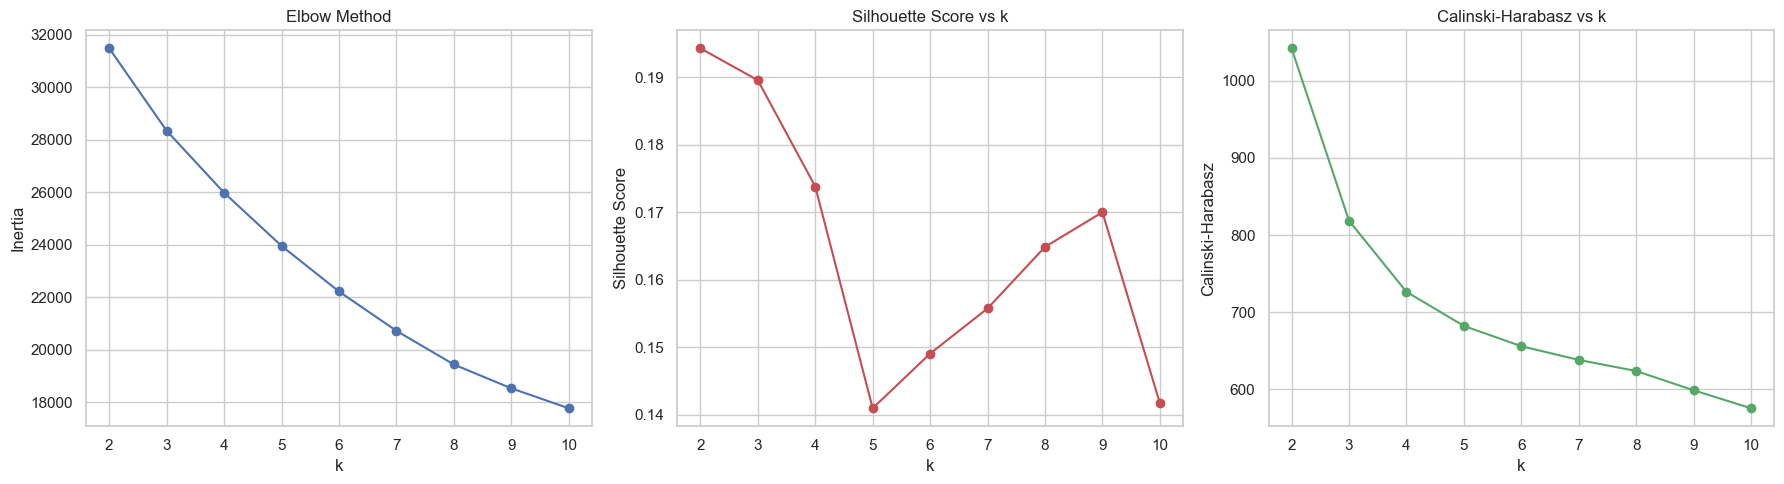

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(K_RANGE, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_RANGE, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')

axes[2].plot(K_RANGE, calinskis, 'go-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz')
axes[2].set_title('Calinski-Harabasz vs k')

plt.tight_layout()
plt.savefig(REPORT_PATH / "clustering_k_selection.png", dpi=150, bbox_inches='tight')
plt.show()

## Entrenar modelo final

In [6]:
# Elegir k basado en metricas (se ajustara tras ver los graficos)
# Probamos k=4 como punto de partida razonable
best_k = 4

# Si silhouette sugiere otro k, descomentar:
# best_k = K_RANGE[np.argmax(silhouettes)]
# print(f"k optimo por silhouette: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, rfm['Cluster'])
cal = calinski_harabasz_score(X_scaled, rfm['Cluster'])

print(f"Modelo final: k={best_k}")
print(f"Silhouette score: {sil:.4f}")
print(f"Calinski-Harabasz: {cal:.1f}")
print(f"\nDistribucion de clusters:")
print(rfm['Cluster'].value_counts().sort_index())

Modelo final: k=4
Silhouette score: 0.1737
Calinski-Harabasz: 726.4

Distribucion de clusters:
Cluster
0     780
1     635
2    1595
3    1328
Name: count, dtype: int64


## Analisis de centroides

In [7]:
# Promedios por cluster (valores originales, no escalados)
centroid_cols = FEATURES + ['Cluster']
centroids = rfm[['Recency','Frequency','Monetary','Cancel_rate',
                  'pct_with_color','color_diversity','pct_with_material',
                  'avg_quantity_in_set','pct_purchases_sets','Cluster']].groupby('Cluster').mean().round(2)

print("Centroides (valores originales promedio):")
print(centroids.to_string())

print(f"\nTamano de clusters:")
for c in sorted(rfm['Cluster'].unique()):
    n = (rfm['Cluster'] == c).sum()
    print(f"  Cluster {c}: {n} clientes ({n/len(rfm)*100:.1f}%)")

Centroides (valores originales promedio):
         Recency  Frequency  Monetary  Cancel_rate  pct_with_color  color_diversity  pct_with_material  avg_quantity_in_set  pct_purchases_sets
Cluster                                                                                                                                        
0         126.54       1.64    470.94        12.16           11.77             0.41              20.45                 3.50                5.02
1         105.74       2.16    764.69         1.86           24.24             1.68              15.19                30.79               20.05
2          31.02       8.58   4278.43         2.81           28.80             2.36              16.10                12.54                7.62
3         140.14       1.66    479.13         1.55           39.91             1.81              17.22                 4.00                4.31

Tamano de clusters:
  Cluster 0: 780 clientes (18.0%)
  Cluster 1: 635 clientes (14.6%)
  Clu

## Visualizacion: Boxplots por cluster

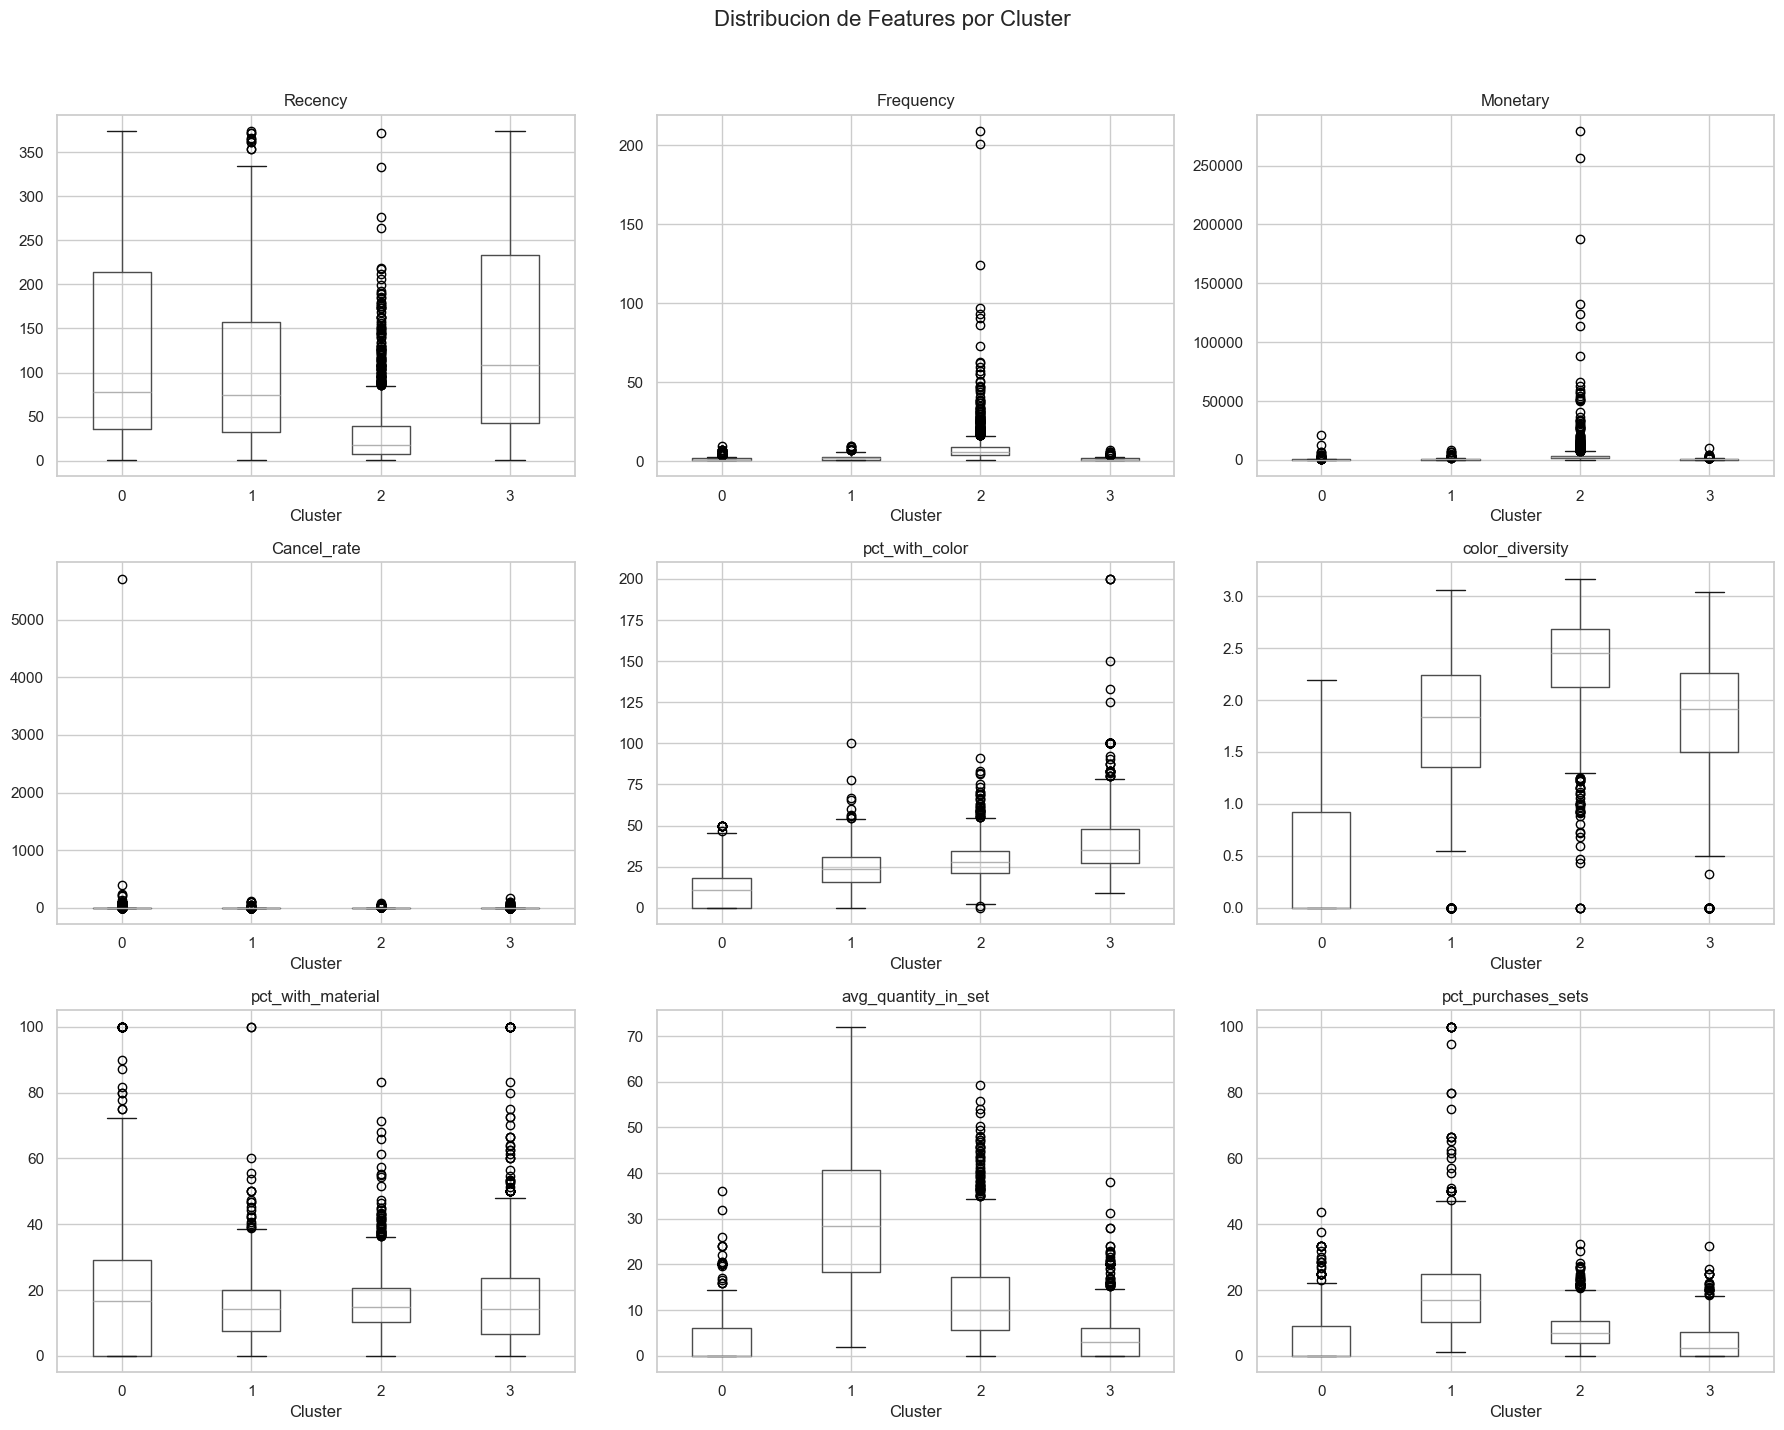

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    rfm.boxplot(column=feat, by='Cluster', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Cluster')

plt.suptitle('Distribucion de Features por Cluster', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_PATH / "clustering_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

## Analisis de variables categoricas por cluster

Cluster 0 - Top 5 colores: {'red': np.int64(431), 'pink': np.int64(85), 'white': np.int64(82), 'silver': np.int64(48), 'blue': np.int64(39)}
Cluster 1 - Top 5 colores: {'red': np.int64(348), 'pink': np.int64(177), 'white': np.int64(38), 'blue': np.int64(20), 'cream': np.int64(13)}
Cluster 2 - Top 5 colores: {'red': np.int64(890), 'pink': np.int64(247), 'white': np.int64(244), 'blue': np.int64(75), 'silver': np.int64(60)}
Cluster 3 - Top 5 colores: {'red': np.int64(539), 'pink': np.int64(271), 'white': np.int64(247), 'blue': np.int64(75), 'cream': np.int64(63)}

Cluster 0 - Top 5 materiales: {'tin': np.int64(279), 'metal': np.int64(117), 'wooden': np.int64(110), 'paper': np.int64(108), 'glass': np.int64(87)}
Cluster 1 - Top 5 materiales: {'paper': np.int64(202), 'tin': np.int64(167), 'metal': np.int64(84), 'wooden': np.int64(71), 'glass': np.int64(48)}
Cluster 2 - Top 5 materiales: {'metal': np.int64(381), 'paper': np.int64(287), 'tin': np.int64(268), 'wooden': np.int64(248), 'glass': n

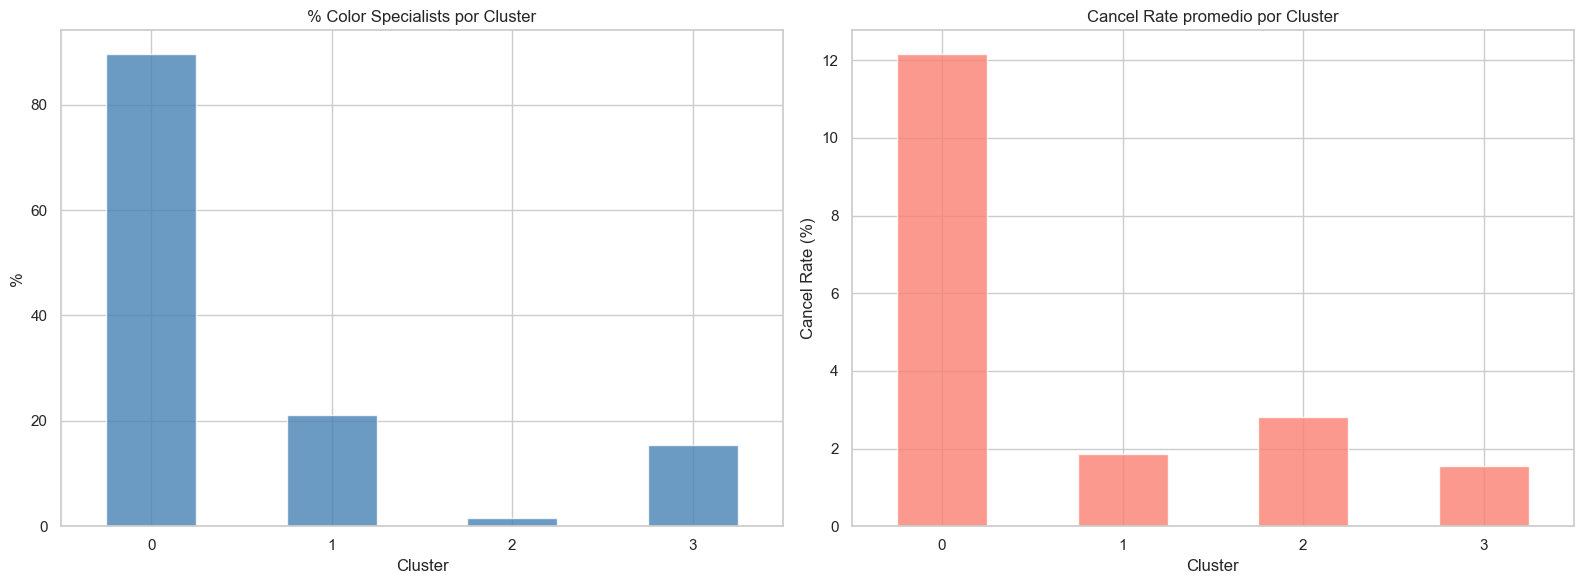

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dominant color por cluster
for c in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == c]
    top_colors = subset['dominant_color'].value_counts().head(5)
    print(f"Cluster {c} - Top 5 colores: {dict(top_colors)}")

# Dominant material por cluster
print()
for c in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == c]
    top_mats = subset['dominant_material'].value_counts().head(5)
    print(f"Cluster {c} - Top 5 materiales: {dict(top_mats)}")

# Grafico: color specialist por cluster
specialist_rate = rfm.groupby('Cluster')['is_color_specialist'].mean() * 100
specialist_rate.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('% Color Specialists por Cluster')
axes[0].set_ylabel('%')
axes[0].set_xlabel('Cluster')
axes[0].tick_params(axis='x', rotation=0)

# Grafico: cancel rate por cluster
cancel_rate = rfm.groupby('Cluster')['Cancel_rate'].mean()
cancel_rate.plot(kind='bar', ax=axes[1], color='salmon', alpha=0.8)
axes[1].set_title('Cancel Rate promedio por Cluster')
axes[1].set_ylabel('Cancel Rate (%)')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(REPORT_PATH / "clustering_categorical.png", dpi=150, bbox_inches='tight')
plt.show()

## Heatmap de centroides normalizados

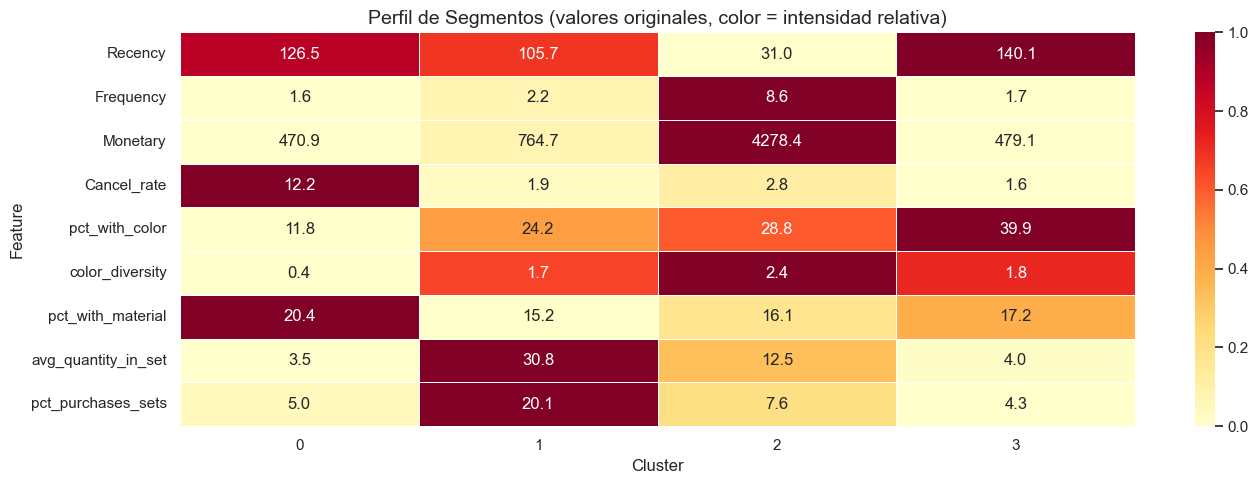

In [10]:
# Normalizar centroides para heatmap (min-max por feature)
centroids_norm = centroids.copy()
for col in centroids_norm.columns:
    cmin = centroids_norm[col].min()
    cmax = centroids_norm[col].max()
    if cmax > cmin:
        centroids_norm[col] = (centroids_norm[col] - cmin) / (cmax - cmin)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(centroids_norm.T, annot=centroids.T.values, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Perfil de Segmentos (valores originales, color = intensidad relativa)', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(REPORT_PATH / "clustering_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## Etiquetas de negocio

Basandose en los centroides:

| Cluster | Etiqueta | Perfil | % Clientes | % Revenue |
|---------|----------|--------|------------|-----------|
| 0 | **En Riesgo** | Recency media, baja frecuencia, **cancel rate muy alto (12.2%)**, poco color | 18.0% | 4.4% |
| 1 | **Compradores de Sets** | Recency media, frecuencia baja-media, **alto avg_quantity_in_set (30.8)** y pct_purchases_sets (20%) | 14.6% | 5.8% |
| 2 | **VIP** | **Recency baja (31d), alta frecuencia (8.6), alto monetary ($4,278)**, diversificados en color | 36.8% | 82.1% |
| 3 | **Dormidos** | **Recency alta (140d)**, baja frecuencia, bajo monetary, pero cancel rate bajo | 30.6% | 7.7% |

In [11]:
LABELS = {
    0: 'En Riesgo',
    1: 'Compradores de Sets',
    2: 'VIP',
    3: 'Dormidos'
}

rfm['Segment_label'] = rfm['Cluster'].map(LABELS)

# Resumen por segmento
summary = rfm.groupby(['Cluster', 'Segment_label']).agg(
    n_clientes=('CustomerID', 'count'),
    recency_mean=('Recency', 'mean'),
    frequency_mean=('Frequency', 'mean'),
    monetary_mean=('Monetary', 'mean'),
    monetary_total=('Monetary', 'sum'),
    cancel_rate_mean=('Cancel_rate', 'mean'),
).round(1)

summary['pct_clientes'] = (summary['n_clientes'] / summary['n_clientes'].sum() * 100).round(1)
summary['pct_revenue'] = (summary['monetary_total'] / summary['monetary_total'].sum() * 100).round(1)

print("Resumen de segmentos:")
print(summary.to_string())

Resumen de segmentos:
                             n_clientes  recency_mean  frequency_mean  monetary_mean  monetary_total  cancel_rate_mean  pct_clientes  pct_revenue
Cluster Segment_label                                                                                                                            
0       En Riesgo                   780         126.5             1.6          470.9        367335.3              12.2          18.0          4.4
1       Compradores de Sets         635         105.7             2.2          764.7        485576.6               1.9          14.6          5.8
2       VIP                        1595          31.0             8.6         4278.4       6824100.5               2.8          36.8         82.1
3       Dormidos                   1328         140.1             1.7          479.1        636282.4               1.6          30.6          7.7


## Guardar resultados

In [12]:
# Guardar modelo
with open(MODEL_PATH / "kmeans_model.pkl", 'wb') as f:
    pickle.dump({'model': kmeans, 'scaler': scaler, 'features': FEATURES}, f)

# Guardar clientes segmentados
rfm.to_parquet(OUTPUT_PATH / "clientes_segmentados.parquet", index=False)

print(f"Modelo guardado: {MODEL_PATH / 'kmeans_model.pkl'}")
print(f"Clientes segmentados: {OUTPUT_PATH / 'clientes_segmentados.parquet'}")
print(f"Shape: {rfm.shape}")

Modelo guardado: ../../data/06_models/kmeans_model.pkl
Clientes segmentados: ../../data/07_model_output/clientes_segmentados.parquet
Shape: (4338, 15)


## Comparacion: RFM solo vs RFM + atributos de producto

Para cuantificar el aporte del enriquecimiento con regex, comparamos el clustering
usando solo las 4 variables RFM tradicionales contra el modelo completo con 9 features.

In [13]:
# Clustering con RFM solo (4 features)
RFM_ONLY = ['Recency', 'Frequency', 'Monetary', 'Cancel_rate']

X_rfm_raw = rfm[RFM_ONLY].copy()
for col in ['Frequency', 'Monetary', 'Cancel_rate']:
    X_rfm_raw[col] = np.log1p(X_rfm_raw[col])

scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm_raw)

# Evaluar ambos modelos para k=2..10
results = []
for k in range(2, 11):
    # RFM solo
    km_rfm = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_rfm = km_rfm.fit_predict(X_rfm_scaled)
    sil_rfm = silhouette_score(X_rfm_scaled, labels_rfm)
    cal_rfm = calinski_harabasz_score(X_rfm_scaled, labels_rfm)

    # RFM + producto (ya calculado, recalcular para consistencia)
    km_full = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km_full.fit_predict(X_scaled)
    sil_full = silhouette_score(X_scaled, labels_full)
    cal_full = calinski_harabasz_score(X_scaled, labels_full)

    results.append({
        'k': k,
        'sil_rfm': sil_rfm, 'cal_rfm': cal_rfm,
        'sil_full': sil_full, 'cal_full': cal_full
    })

comp = pd.DataFrame(results)
print(comp.to_string(index=False))

 k  sil_rfm     cal_rfm  sil_full    cal_full
 2 0.337159 2382.712441  0.194270 1042.138679
 3 0.332826 2241.724199  0.189546  818.632564
 4 0.365899 2478.234272  0.173795  726.411407
 5 0.332825 2406.473377  0.140948  682.185513
 6 0.343948 2339.381716  0.149050  655.898228
 7 0.347375 2228.967993  0.155738  638.128035
 8 0.306550 2180.764148  0.164853  623.706290
 9 0.294280 2110.642361  0.169989  598.760764
10 0.301544 2073.978180  0.141704  575.405541


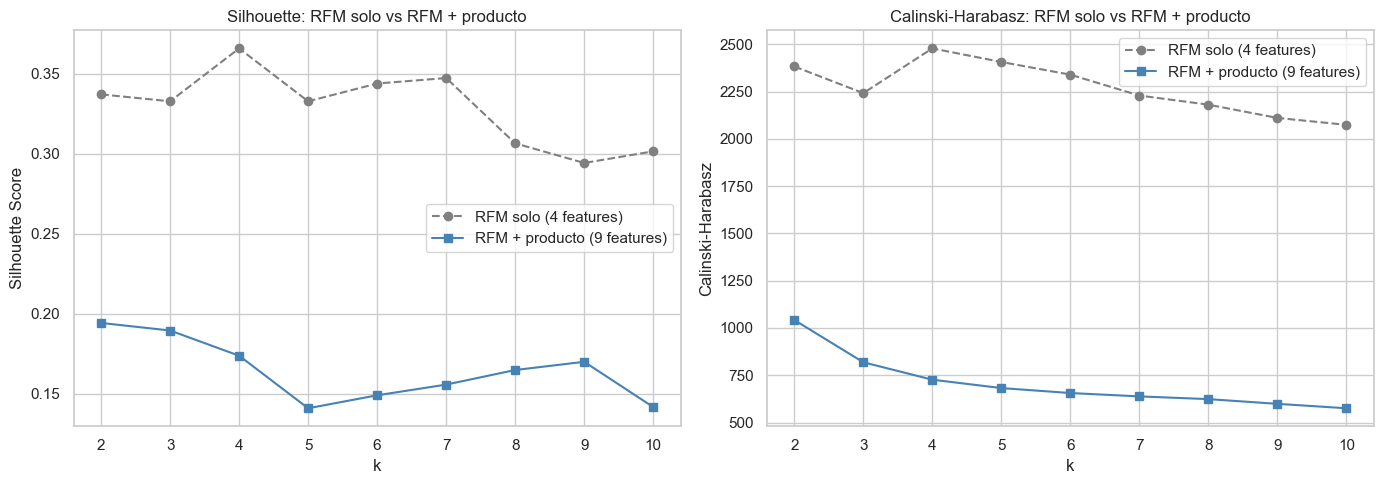

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(comp['k'], comp['sil_rfm'], 'o--', label='RFM solo (4 features)', color='gray')
axes[0].plot(comp['k'], comp['sil_full'], 's-', label='RFM + producto (9 features)', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette: RFM solo vs RFM + producto')
axes[0].legend()

axes[1].plot(comp['k'], comp['cal_rfm'], 'o--', label='RFM solo (4 features)', color='gray')
axes[1].plot(comp['k'], comp['cal_full'], 's-', label='RFM + producto (9 features)', color='steelblue')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Calinski-Harabasz')
axes[1].set_title('Calinski-Harabasz: RFM solo vs RFM + producto')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_PATH / "clustering_rfm_vs_full.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Comparar perfiles con k=4
km_rfm_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm['Cluster_rfm_only'] = km_rfm_4.fit_predict(X_rfm_scaled)

sil_rfm4 = silhouette_score(X_rfm_scaled, rfm['Cluster_rfm_only'])
sil_full4 = silhouette_score(X_scaled, rfm['Cluster'])

print("=== Comparacion con k=4 ===")
print(f"Silhouette RFM solo:     {sil_rfm4:.4f}")
print(f"Silhouette RFM+producto: {sil_full4:.4f}")
print()

# Tabla de contingencia: como se redistribuyen los clientes
ct = pd.crosstab(rfm['Cluster'], rfm['Cluster_rfm_only'],
                 margins=True, margins_name='Total')
ct.index = [LABELS.get(i, i) for i in ct.index]
ct.columns = [f'RFM_cluster_{c}' if c != 'Total' else c for c in ct.columns]
print("Tabla de contingencia (filas=RFM+prod, cols=RFM solo):")
print(ct.to_string())
print()

# El segmento "Compradores de Sets" no existe en RFM solo
rfm_only_centroids = rfm.groupby('Cluster_rfm_only')[RFM_ONLY].mean().round(1)
print("Centroides RFM solo (no captura preferencias de producto):")
print(rfm_only_centroids.to_string())

# Limpiar columna temporal
rfm.drop(columns=['Cluster_rfm_only'], inplace=True)

=== Comparacion con k=4 ===
Silhouette RFM solo:     0.3659
Silhouette RFM+producto: 0.1737

Tabla de contingencia (filas=RFM+prod, cols=RFM solo):
                     RFM_cluster_0  RFM_cluster_1  RFM_cluster_2  RFM_cluster_3  Total
En Riesgo                       23            414            106            237    780
Compradores de Sets             54            395             49            137    635
VIP                           1113            320            161              1   1595
Dormidos                         7            721            112            488   1328
Total                         1197           1850            428            863   4338

Centroides RFM solo (no captura preferencias de producto):
                  Recency  Frequency  Monetary  Cancel_rate
Cluster_rfm_only                                           
0                    27.8       10.3    5395.3          1.5
1                    54.1        2.1     638.6          0.2
2                   107.9     

## Conclusion

**Modelo:** K-Means con k=4 sobre 9 features (RFM + atributos de producto), con log-transform y StandardScaler.

**Metricas:**
- Silhouette score: 0.174 (modesto pero esperado con features mixtos RFM + producto)
- Calinski-Harabasz: 726.4
- Sin clusters degenerados (rango 14.6% - 36.8%)

**Segmentos identificados:**
- **VIP (36.8% clientes, 82.1% revenue):** Recientes, frecuentes, alto gasto. Core del negocio.
- **Dormidos (30.6%, 7.7% revenue):** Alta recency, baja frecuencia. Candidatos a reactivacion.
- **En Riesgo (18.0%, 4.4% revenue):** Cancel rate 6x mayor que otros segmentos. Requieren atencion.
- **Compradores de Sets (14.6%, 5.8% revenue):** Patron de compra distintivo por sets/packs.

**Comparacion RFM solo vs RFM + producto:**
- El modelo enriquecido detecta el segmento "Compradores de Sets" que RFM solo no puede identificar
- La tabla de contingencia muestra redistribucion significativa de clientes entre los dos enfoques
- Los atributos de producto aportan informacion ortogonal que justifica el enriquecimiento realizado

**Valor de negocio:**
- Confirma patron Pareto: 37% de clientes genera 82% del revenue
- El segmento "En Riesgo" tiene cancel rate de 12.2% vs ~2% en otros segmentos
- Los atributos de producto discriminan segmentos que RFM solo no detectaria

**Proximos pasos:**
1. Modelo de prediccion de churn (notebook 08)
2. Cruzar segmentos con predicciones de churn (notebook 09)
3. Prototipo interactivo con segmentacion (Streamlit)